
# Generative modelling of cascading extremes with a Transformer

This practical uses **one long simulated multivariate process** to illustrate the basic generative idea.

We will:

1. simulate a 5-dimensional **VAR(5)** process with GARCH-like volatility and heavy-tailed innovations;
2. turn continuous extremes into categorical tokens using a **probability-scale rule** at \(q=0.98\);
3. fit a small causal Transformer to
   \[
   p_\theta(Z_{t+1}\mid Z_{t-L+1:t});
   \]
4. check whether the learned conditional probabilities reproduce **cascades of extremes**, then sample new extreme-event sequences.

There is deliberately **no amortisation** and only one fixed data-generating process. The goal is to make the modelling pipeline visible from beginning to end.


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu



## 1. Simulate a VAR(5) process with clustered volatility

Let \(X_t\in\mathbb{R}^5\). We simulate

\[
X_t
=
\sum_{\ell=1}^{5} A_\ell X_{t-\ell}
+
\varepsilon_t,
\qquad
\varepsilon_t=D_t z_t,
\]

with

\[
D_t=\operatorname{diag}\!\left(\sqrt{h_{1,t}},\ldots,\sqrt{h_{5,t}}\right).
\]

The conditional variance is updated using a simple multivariate GARCH-like rule,

\[
h_{i,t}
=
\omega
+\beta h_{i,t-1}
+\alpha \varepsilon_{i,t-1}^{2}
+\gamma\frac{1}{5}\sum_{j=1}^{5}\varepsilon_{j,t-1}^{2}.
\]

The final term creates a **common volatility channel**: a large shock in one component can raise future volatility throughout the system.

The innovations \(z_t\) are correlated Student-\(t\) variables. Hence the process contains:

- temporal dependence through the VAR(5);
- cross-component propagation through off-diagonal VAR coefficients;
- volatility clustering through \(h_t\);
- heavy tails and simultaneous large shocks through Student-\(t\) innovations.


In [2]:

def simulate_var5_garch(T=40_000, burn=2_000, seed=SEED):
    rng = np.random.default_rng(seed)

    d = 5
    p = 5

    # A fixed cross-component interaction matrix.
    # Lag weights decay, so recent lags matter most.
    B = np.array([
        [0.34, 0.07, 0.00, 0.03, 0.00],
        [0.04, 0.32, 0.07, 0.00, 0.02],
        [0.02, 0.05, 0.35, 0.06, 0.00],
        [0.00, 0.03, 0.05, 0.31, 0.08],
        [0.05, 0.00, 0.03, 0.05, 0.33],
    ])

    lag_weights = np.array([0.48, 0.24, 0.14, 0.09, 0.05])
    A = lag_weights[:, None, None] * B[None, :, :]

    # Correlated multivariate Student-t innovations.
    R = np.full((d, d), 0.25)
    np.fill_diagonal(R, 1.0)
    chol_R = np.linalg.cholesky(R)
    df = 5.0

    # GARCH-like volatility parameters.
    omega = 0.02
    alpha = 0.06
    beta = 0.90
    gamma = 0.02

    n = T + burn
    x = np.zeros((n, d))
    h = np.ones((n, d))
    shock = np.zeros((n, d))

    for t in range(p, n):
        previous_shock_sq = shock[t - 1] ** 2

        h[t] = (
            omega
            + beta * h[t - 1]
            + alpha * previous_shock_sq
            + gamma * previous_shock_sq.mean()
        )

        # True multivariate Student-t draw:
        # correlated Gaussian divided by a common chi-square scale.
        g = chol_R @ rng.normal(size=d)
        z = g / np.sqrt(rng.chisquare(df) / df)

        # Rescale so each marginal innovation has variance approximately one.
        z *= np.sqrt((df - 2.0) / df)

        conditional_mean = np.zeros(d)
        for lag in range(1, p + 1):
            conditional_mean += A[lag - 1] @ x[t - lag]

        shock[t] = np.sqrt(h[t]) * z
        x[t] = conditional_mean + shock[t]

    return x[burn:], h[burn:], A


X, H, A = simulate_var5_garch()

print("X shape:", X.shape)
print("marginal standard deviations:", np.round(X.std(axis=0), 3))
print("98% marginal quantiles:", np.round(np.quantile(X, 0.98, axis=0), 3))


X shape: (40000, 5)
marginal standard deviations: [1.071 1.088 1.098 1.083 1.048]
98% marginal quantiles: [2.273 2.241 2.225 2.241 2.232]


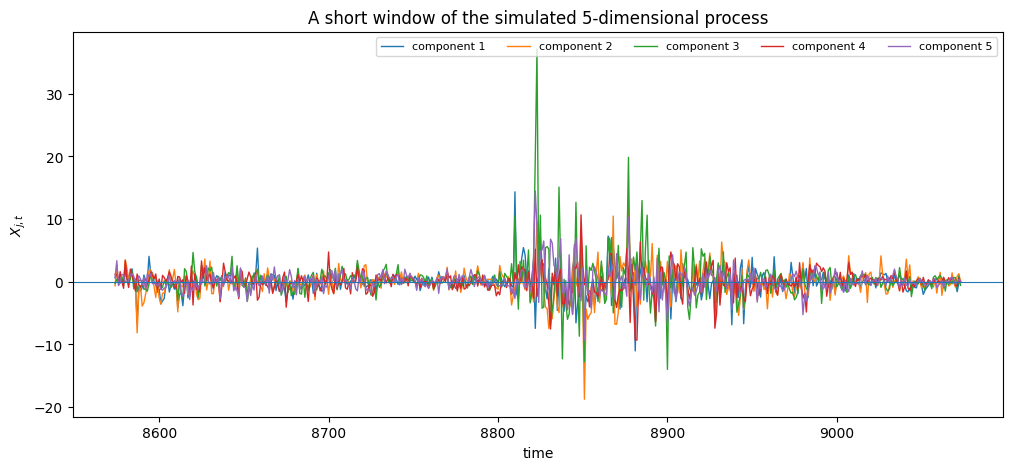

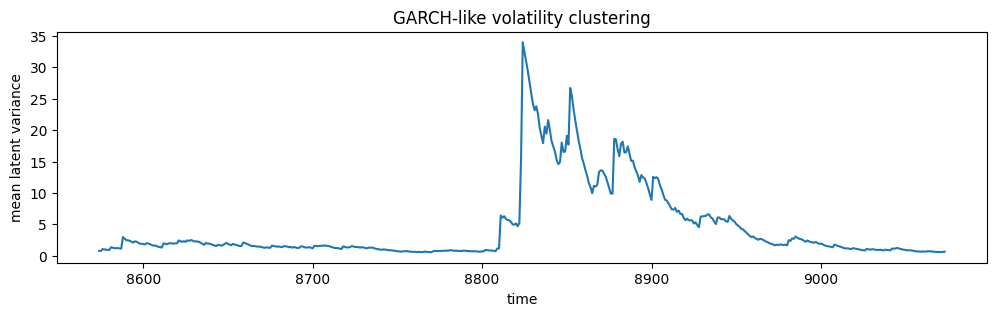

In [3]:

# Show a short window. A volatility burst is easier to see if we centre
# the plot near the largest average latent variance.

window = 500
centre = np.argmax(H.mean(axis=1))
start = max(0, min(len(X) - window, centre - window // 2))
stop = start + window

plt.figure(figsize=(12, 5))
for j in range(X.shape[1]):
    plt.plot(np.arange(start, stop), X[start:stop, j], linewidth=1, label=f"component {j+1}")
plt.axhline(0, linewidth=0.8)
plt.xlabel("time")
plt.ylabel(r"$X_{j,t}$")
plt.title("A short window of the simulated 5-dimensional process")
plt.legend(ncol=5, fontsize=8)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(np.arange(start, stop), H[start:stop].mean(axis=1), linewidth=1.5)
plt.xlabel("time")
plt.ylabel("mean latent variance")
plt.title("GARCH-like volatility clustering")
plt.show()



## 2. Tokenise extremes on a common probability scale

We split the process chronologically and estimate all thresholds **using the training period only**.

For component \(j\),

\[
u_j = \widehat F_j^{-1}(q),
\qquad q=0.98.
\]

Above \(u_j\), we fit a simple Pareto tail. If \(n_j\) training observations exceed \(u_j\),

\[
\widehat\alpha_j
=
\frac{n_j}{
\sum_{t:X_{j,t}>u_j}\log(X_{j,t}/u_j)
}.
\]

For \(x>u_j\), its fitted marginal probability-scale score is

\[
\widehat F_j(x)
=
1-(1-q)
\left(\frac{x}{u_j}\right)^{-\widehat\alpha_j}.
\]

All active components are therefore compared on the same interval \((q,1)\).

We define six tokens:

\[
Z_t =
\begin{cases}
0, & \text{no component exceeds its threshold},\\[1mm]
j, & \text{component }j\text{ has the largest probability-scale score}.
\end{cases}
\]

So token \(0\) means **quiet**, while tokens \(1,\ldots,5\) identify the most marginally extreme component.


In [4]:

Q = 0.98

n = len(X)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

X_train = X[:n_train]
X_val = X[n_train:n_train + n_val]
X_test = X[n_train + n_val:]

thresholds = np.quantile(X_train, Q, axis=0)


def fit_pareto_tail_mle(x, thresholds):
    alpha = np.empty(x.shape[1])

    for j in range(x.shape[1]):
        exceedances = x[:, j][x[:, j] > thresholds[j]]
        alpha[j] = (
            len(exceedances)
            / np.log(exceedances / thresholds[j]).sum()
        )

    return alpha


pareto_alpha = fit_pareto_tail_mle(X_train, thresholds)

print("component   threshold u_j   Pareto alpha")
for j in range(5):
    print(
        f"{j+1:^9d}"
        f"{thresholds[j]:>15.3f}"
        f"{pareto_alpha[j]:>15.3f}"
    )


component   threshold u_j   Pareto alpha
    1              2.261          3.115
    2              2.291          3.014
    3              2.224          2.921
    4              2.222          3.208
    5              2.225          2.901


In [5]:

def probability_scale_tokens(x, thresholds, alpha, q=0.98):
    n, d = x.shape

    active = x > thresholds
    scores = np.full((n, d), -np.inf)

    for j in range(d):
        mask = active[:, j]

        scores[mask, j] = (
            1.0
            - (1.0 - q)
            * (x[mask, j] / thresholds[j]) ** (-alpha[j])
        )

    tokens = np.zeros(n, dtype=np.int64)

    any_extreme = active.any(axis=1)
    tokens[any_extreme] = (
        scores[any_extreme].argmax(axis=1) + 1
    )

    return tokens


tokens = probability_scale_tokens(
    X,
    thresholds=thresholds,
    alpha=pareto_alpha,
    q=Q,
)

tokens_train = tokens[:n_train]
tokens_val = tokens[n_train:n_train + n_val]
tokens_test = tokens[n_train + n_val:]

freq = np.bincount(tokens_train, minlength=6) / len(tokens_train)

print("Training token frequencies")
for token, p in enumerate(freq):
    label = "quiet" if token == 0 else f"component {token}"
    print(f"token {token}: {p:7.4f}   ({label})")

print(f"\nProbability of any extreme token: {1 - freq[0]:.4f}")


Training token frequencies
token 0:  0.9261   (quiet)
token 1:  0.0148   (component 1)
token 2:  0.0141   (component 2)
token 3:  0.0149   (component 3)
token 4:  0.0150   (component 4)
token 5:  0.0150   (component 5)

Probability of any extreme token: 0.0739


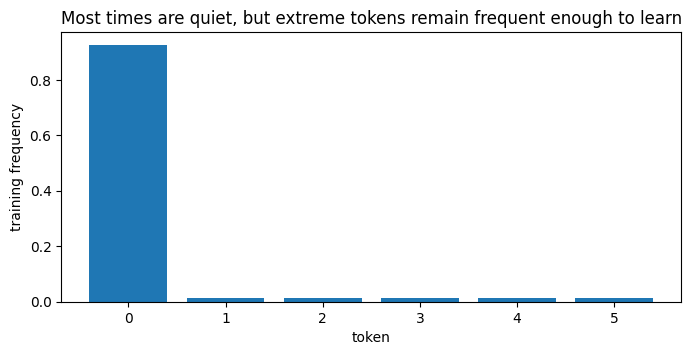

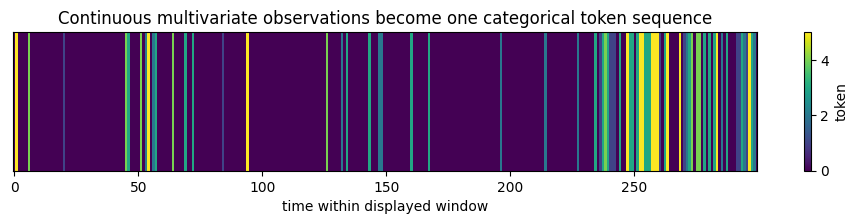

In [6]:

plt.figure(figsize=(8, 3.5))
plt.bar(np.arange(6), freq)
plt.xticks(np.arange(6))
plt.xlabel("token")
plt.ylabel("training frequency")
plt.title("Most times are quiet, but extreme tokens remain frequent enough to learn")
plt.show()

# A short categorical strip makes the sequential representation explicit.
token_start = start
token_stop = min(start + 300, len(tokens))

plt.figure(figsize=(12, 1.8))
plt.imshow(tokens[token_start:token_stop][None, :], aspect="auto", interpolation="nearest")
plt.yticks([])
plt.xlabel("time within displayed window")
plt.title("Continuous multivariate observations become one categorical token sequence")
plt.colorbar(label="token")
plt.show()



## 3. Fit a small causal Transformer

The Transformer sees **only the token sequence**. It does not observe \(X_t\), \(h_t\), the VAR matrices, or the simulation parameters.

Given a context of length \(L\), it learns

\[
p_\theta
\left(
Z_{t+1}
\mid
Z_{t-L+1:t}
\right).
\]

Training minimises the autoregressive negative log-likelihood,

\[
\mathcal L(\theta)
=
-\sum_t
\log
p_\theta
\left(
Z_{t+1}
\mid
Z_{\leq t}
\right).
\]

We deliberately use a small network: two Transformer layers and a six-category output distribution.


In [7]:

class ExtremeTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=6,
        context_len=32,
        d_model=32,
        nhead=4,
        num_layers=2,
        dropout=0.10,
    ):
        super().__init__()

        self.context_len = context_len

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(context_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=num_layers,
        )

        self.norm = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape

        positions = torch.arange(
            sequence_length,
            device=token_ids.device,
        )

        h = (
            self.token_embedding(token_ids)
            + self.position_embedding(positions)[None, :, :]
        )

        # True above the diagonal means "do not attend to the future".
        causal_mask = torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                dtype=torch.bool,
                device=token_ids.device,
            ),
            diagonal=1,
        )

        h = self.transformer(h, mask=causal_mask)
        h = self.norm(h)

        return self.output(h)


In [8]:

CONTEXT_LEN = 24
VOCAB_SIZE = 6
BATCH_SIZE = 128

train_tensor = torch.tensor(tokens_train, dtype=torch.long)
val_tensor = torch.tensor(tokens_val, dtype=torch.long)
test_tensor = torch.tensor(tokens_test, dtype=torch.long)


def random_batch(sequence, batch_size, context_len):
    starts = torch.randint(
        0,
        len(sequence) - context_len - 1,
        (batch_size,),
    )

    offsets = torch.arange(context_len)
    index = starts[:, None] + offsets[None, :]

    x = sequence[index]
    y = sequence[index + 1]

    return x.to(device), y.to(device)


model = ExtremeTransformer(
    vocab_size=VOCAB_SIZE,
    context_len=CONTEXT_LEN,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)

# Enough for the demonstration while remaining practical on a CPU.
N_STEPS = 500 if device.type == "cuda" else 200

training_loss = []

model.train()

for step in range(1, N_STEPS + 1):
    x_batch, y_batch = random_batch(
        train_tensor,
        BATCH_SIZE,
        CONTEXT_LEN,
    )

    logits = model(x_batch)

    loss = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        y_batch.reshape(-1),
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    training_loss.append(loss.item())

    if step == 1 or step % 50 == 0:
        print(f"step {step:4d} | training NLL {loss.item():.4f}")


step    1 | training NLL 2.6513


step   50 | training NLL 0.4621


step  100 | training NLL 0.3833


step  150 | training NLL 0.3706


step  200 | training NLL 0.3777


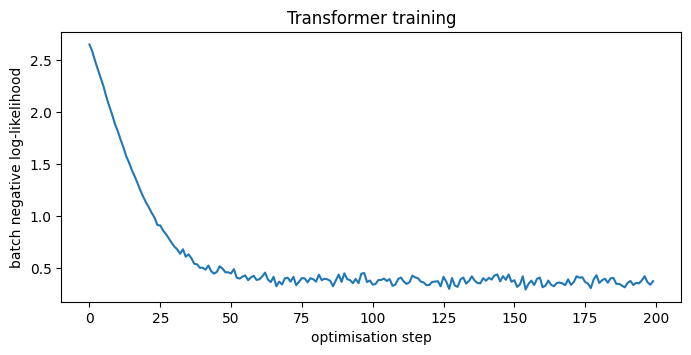

In [9]:

plt.figure(figsize=(8, 3.5))
plt.plot(training_loss)
plt.xlabel("optimisation step")
plt.ylabel("batch negative log-likelihood")
plt.title("Transformer training")
plt.show()



## 4. Diagnose conditional probabilities and generate cascades

A low loss is useful, but our scientific question is more specific:

> **Has the Transformer learned how extreme events propagate through time?**

We use two simple diagnostics.

First, compare the observed and learned one-step transition probabilities,

\[
P(Z_{t+1}=j\mid Z_t=i).
\]

Because the Transformer conditions on the full context, its entry for row \(i\) is obtained by **averaging its predicted distributions over all test contexts whose current token is \(i\)**.

Second, define

\[
E_t=\mathbf 1(Z_t\neq 0),
\]

and compare the cascade curve

\[
P(E_{t+h}=1\mid E_t=1),
\qquad h=1,\ldots,10.
\]

This directly checks whether an extreme now is followed by an elevated probability of further extremes.


In [10]:

@torch.inference_mode()
def one_step_test_predictions(
    model,
    sequence,
    context_len,
    batch_size=512,
):
    model.eval()

    sequence = torch.as_tensor(sequence, dtype=torch.long)

    # Context ending at t predicts token t+1.
    current_indices = np.arange(
        context_len - 1,
        len(sequence) - 1,
    )

    contexts = torch.stack([
        sequence[t - context_len + 1:t + 1]
        for t in current_indices
    ])

    probabilities = []

    for start_batch in range(0, len(contexts), batch_size):
        x_batch = contexts[
            start_batch:start_batch + batch_size
        ].to(device)

        next_logits = model(x_batch)[:, -1, :]
        probabilities.append(
            next_logits.softmax(dim=-1).cpu()
        )

    probabilities = torch.cat(probabilities).numpy()

    current = np.asarray(sequence[current_indices])
    target = np.asarray(sequence[current_indices + 1])

    return current, target, probabilities


current_test, target_test, test_probs = one_step_test_predictions(
    model,
    tokens_test,
    CONTEXT_LEN,
)

transformer_test_nll = -np.log(
    test_probs[np.arange(len(target_test)), target_test] + 1e-12
).mean()

# An unconditional categorical baseline ignores all history.
iid_prob = np.bincount(tokens_train, minlength=VOCAB_SIZE)
iid_prob = iid_prob / iid_prob.sum()

iid_test_nll = -np.log(
    iid_prob[target_test] + 1e-12
).mean()

print(f"Transformer test NLL: {transformer_test_nll:.4f}")
print(f"IID-token baseline NLL: {iid_test_nll:.4f}")


Transformer test NLL: 0.3899
IID-token baseline NLL: 0.4042


In [11]:

def observed_transition_matrix(current, target, vocab_size=6):
    counts = np.zeros((vocab_size, vocab_size))

    for i, j in zip(current, target):
        counts[i, j] += 1

    row_total = counts.sum(axis=1, keepdims=True)

    return np.divide(
        counts,
        row_total,
        out=np.zeros_like(counts),
        where=row_total > 0,
    )


def transformer_transition_matrix(
    current,
    probabilities,
    vocab_size=6,
):
    matrix = np.zeros((vocab_size, vocab_size))

    for i in range(vocab_size):
        mask = current == i

        if mask.any():
            matrix[i] = probabilities[mask].mean(axis=0)

    return matrix


observed_transition = observed_transition_matrix(
    current_test,
    target_test,
)

model_transition = transformer_transition_matrix(
    current_test,
    test_probs,
)

transition_difference = np.abs(
    observed_transition - model_transition
)

print(
    "Mean absolute transition-probability error:",
    f"{transition_difference.mean():.4f}",
)


Mean absolute transition-probability error: 0.0415


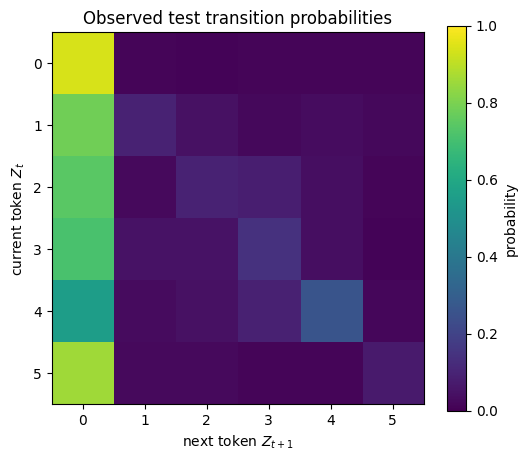

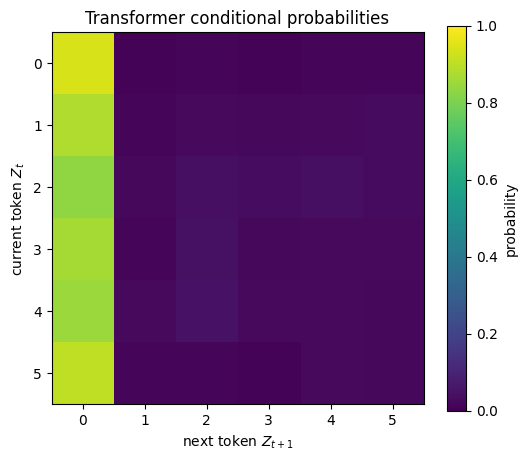

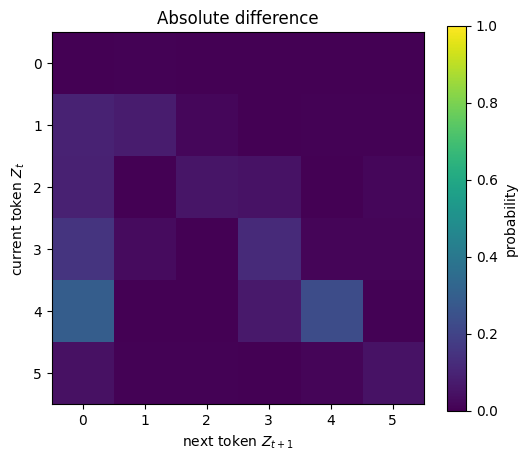

In [12]:

def plot_probability_matrix(matrix, title):
    plt.figure(figsize=(6, 5))
    image = plt.imshow(
        matrix,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    plt.xticks(np.arange(6))
    plt.yticks(np.arange(6))
    plt.xlabel(r"next token $Z_{t+1}$")
    plt.ylabel(r"current token $Z_t$")
    plt.title(title)
    plt.colorbar(image, label="probability")
    plt.show()


plot_probability_matrix(
    observed_transition,
    "Observed test transition probabilities",
)

plot_probability_matrix(
    model_transition,
    "Transformer conditional probabilities",
)

plot_probability_matrix(
    transition_difference,
    "Absolute difference",
)


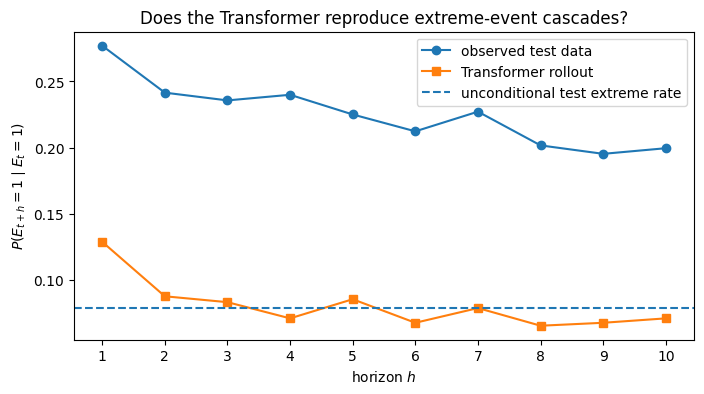

In [13]:

def empirical_cascade_curve(tokens, horizon=10):
    extreme = np.asarray(tokens) != 0
    curve = []

    for h in range(1, horizon + 1):
        extreme_now = extreme[:-h]
        extreme_later = extreme[h:]
        curve.append(
            extreme_later[extreme_now].mean()
        )

    return np.asarray(curve)


@torch.inference_mode()
def transformer_cascade_curve(
    model,
    tokens,
    context_len,
    horizon=10,
    n_contexts=300,
    repeats=3,
    seed=SEED,
):
    model.eval()

    sequence = torch.as_tensor(tokens, dtype=torch.long)

    eligible = np.where(
        np.asarray(tokens)[context_len - 1:-1] != 0
    )[0] + context_len - 1

    rng = np.random.default_rng(seed)

    if len(eligible) > n_contexts:
        eligible = rng.choice(
            eligible,
            size=n_contexts,
            replace=False,
        )

    contexts = torch.stack([
        sequence[t - context_len + 1:t + 1]
        for t in eligible
    ])

    # Repeating contexts gives a cheap Monte Carlo average.
    contexts = contexts.repeat_interleave(
        repeats,
        dim=0,
    ).to(device)

    generator = torch.Generator(
        device=device
    ).manual_seed(seed)

    curve = []

    for _ in range(horizon):
        probs = model(contexts)[:, -1, :].softmax(dim=-1)

        next_token = torch.multinomial(
            probs,
            num_samples=1,
            generator=generator,
        ).squeeze(1)

        curve.append(
            (next_token != 0).float().mean().item()
        )

        contexts = torch.cat(
            [contexts[:, 1:], next_token[:, None]],
            dim=1,
        )

    return np.asarray(curve)


HORIZON = 10

observed_cascade = empirical_cascade_curve(
    tokens_test,
    horizon=HORIZON,
)

model_cascade = transformer_cascade_curve(
    model,
    tokens_test,
    CONTEXT_LEN,
    horizon=HORIZON,
)

unconditional_extreme_rate = np.mean(tokens_test != 0)

lags = np.arange(1, HORIZON + 1)

plt.figure(figsize=(8, 4))
plt.plot(lags, observed_cascade, marker="o", label="observed test data")
plt.plot(lags, model_cascade, marker="s", label="Transformer rollout")
plt.axhline(
    unconditional_extreme_rate,
    linestyle="--",
    label="unconditional test extreme rate",
)
plt.xticks(lags)
plt.xlabel(r"horizon $h$")
plt.ylabel(r"$P(E_{t+h}=1\mid E_t=1)$")
plt.title("Does the Transformer reproduce extreme-event cascades?")
plt.legend()
plt.show()


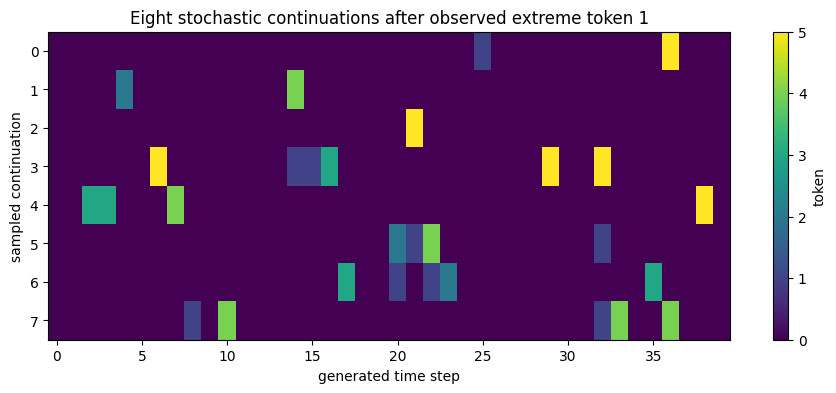

In [14]:

@torch.inference_mode()
def generate_paths(
    model,
    initial_context,
    n_paths=8,
    n_new_tokens=40,
    temperature=1.0,
    seed=SEED,
):
    model.eval()

    context = torch.as_tensor(
        initial_context,
        dtype=torch.long,
        device=device,
    )

    contexts = context[None, :].repeat(
        n_paths,
        1,
    )

    generated = []

    generator = torch.Generator(
        device=device
    ).manual_seed(seed)

    for _ in range(n_new_tokens):
        logits = model(contexts)[:, -1, :] / temperature
        probs = logits.softmax(dim=-1)

        next_token = torch.multinomial(
            probs,
            num_samples=1,
            generator=generator,
        ).squeeze(1)

        generated.append(next_token.cpu().numpy())

        contexts = torch.cat(
            [contexts[:, 1:], next_token[:, None]],
            dim=1,
        )

    return np.stack(generated, axis=1)


# Pick a real test context ending in an extreme token.
eligible = np.where(
    tokens_test[CONTEXT_LEN - 1:-1] != 0
)[0] + CONTEXT_LEN - 1

anchor = eligible[len(eligible) // 2]

initial_context = tokens_test[
    anchor - CONTEXT_LEN + 1:anchor + 1
]

generated_paths = generate_paths(
    model,
    initial_context,
    n_paths=8,
    n_new_tokens=40,
)

plt.figure(figsize=(11, 4))
plt.imshow(
    generated_paths,
    aspect="auto",
    interpolation="nearest",
)
plt.xlabel("generated time step")
plt.ylabel("sampled continuation")
plt.title(
    f"Eight stochastic continuations after observed extreme token {initial_context[-1]}"
)
plt.colorbar(label="token")
plt.show()



### What to take away

The Transformer never saw the continuous VAR-GARCH state. It only saw the categorical sequence \(Z_t\).

Nevertheless, the token history contains information about:

- persistence of volatility;
- which component was recently extreme;
- cross-component spillovers;
- the changing probability that another extreme will occur.

A causal Transformer can therefore be used as a **generative model for extreme-event sequences**:

\[
Z_{t+1}
\sim
p_\theta(\cdot\mid Z_{t-L+1:t}),
\]

then the sampled token is appended to the history and the process is repeated.

For a short practical, the most important diagnostic is not whether every generated sequence looks identical to the data. It is whether the model assigns sensible **conditional probabilities** and reproduces the elevated probability of further extremes after an extreme event.

**Quick experiments if time permits**

- Change `Q = 0.98` to a more or less extreme threshold and inspect the token imbalance.
- Set `gamma = 0` in the simulator and see how the cascade curve changes.
- Reduce `CONTEXT_LEN` and ask whether a shorter history is sufficient to reproduce the cascade.
